In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *

## 1 COLOR

In [4]:
savepath_TS_1_color = "../results/TimeSeries/2D/1_color"
create_folder(savepath_TS_1_color)

Folder already exists: ../results/TimeSeries/2D/1_color


## <b> FIGURE 1 </b>

$P_0 = 100$ (seeds)  
$p_0 = 1.0$ (initial probability)  
$L = 1000$  
$k = 10^{-5}$  
$N_T = 200$


[✔] Image saved to: ../results_paper_SOP/Fig1_carmona.pdf
[✔] Image saved to: ../results_paper_SOP/Fig2_carmona.pdf
[✔] Image saved to: ../results_paper_SOP/Fig3_carmona.pdf
[✔] Image saved to: ../results_paper_SOP/Fig4_carmona.pdf


FileNotFoundError: [Errno 2] No such file or directory: '../Data/bond_percolation/num_colors_1/dim_2/L_1000/NT_constant/NT_200/k_1.0e-05/rho_1.0000e+00/network/P0_0.10_p0_1.00_seed_916333199.npz'

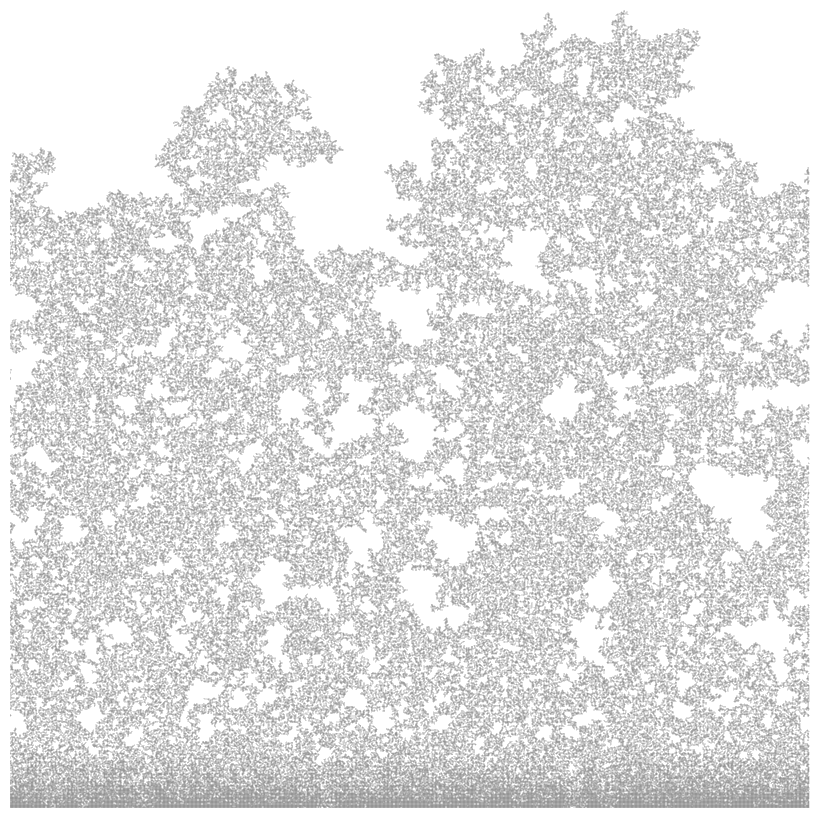

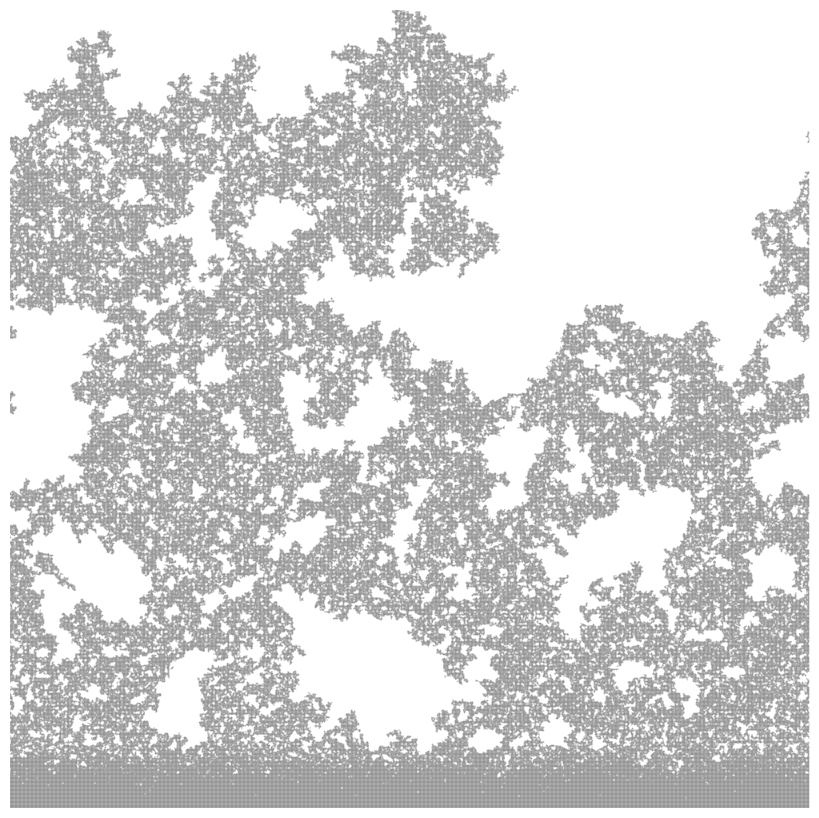

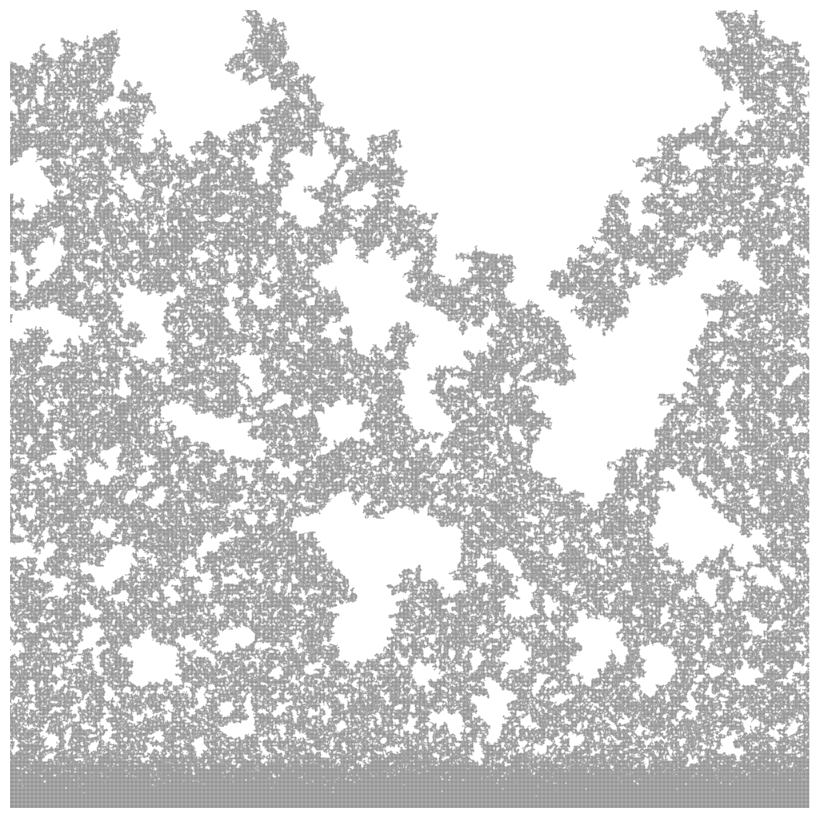

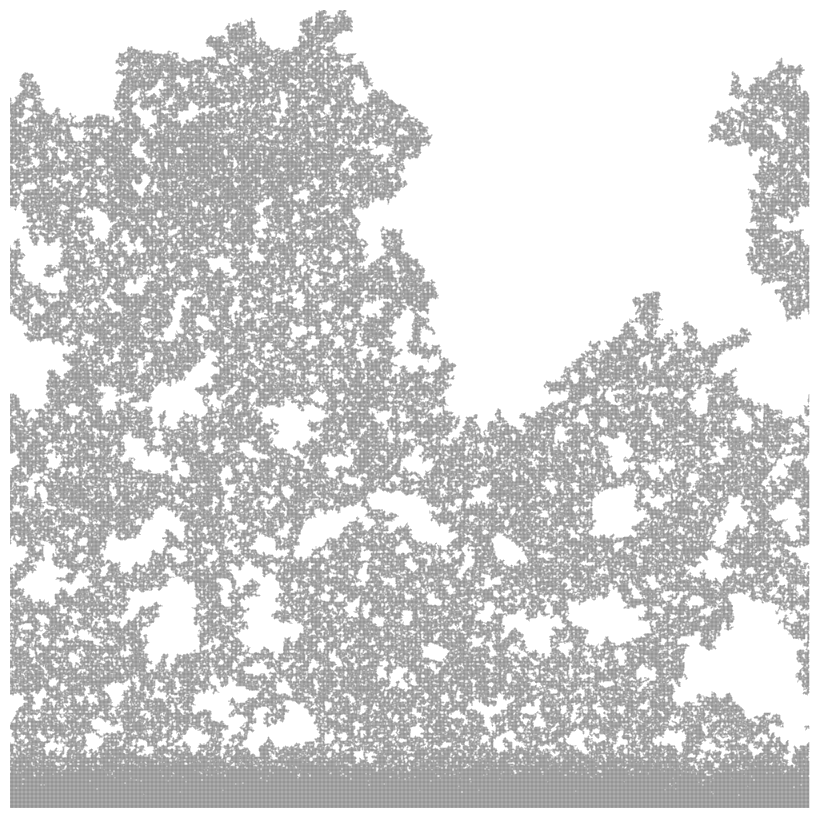

In [ ]:
num_colors = 1
k = 1.0e-05
rho_val = 1.0
path = f"../Data/bond_percolation/num_colors_{num_colors}/dim_2/L_1000/NT_constant/NT_200/k_{k:.1e}/rho_{rho_val:.4e}/network/"
filename = list_npz_files(path)[0]
plot_bond_network(
    path+filename,
    num_colors=num_colors,
    savepath=savepath_TS_1_color + f"/Network.pdf",
    dpi=600,
    min_density=1,
    color_map=None,          # dict[int,str] opcional: {valor_ativo: cor}
    linewidth=0.25,
    figsize=(8, 10),
    show_legend=True
)
    

## <b> FIGURE 2 </b>

Network $2000$ x $2000$ -> $L$ x $L$  
$L = 2000$  
$k = 10^{-4}$  
$N_T = 200$  
$P_0 = 100$ (seeds)  

(a)  
$p_0 = [0.4, 0.8, 1.0]$ (initial probability)  

(b)  
$p_0 = [0.3, 0.7, 1.0]$ (initial probability)  

In [7]:
L = 2000
k = 1.0e-04
Nt = 200
dim = 2
rho = 1.0
prop = "Pt"
type_perc = 'bond'
num_colors = 1

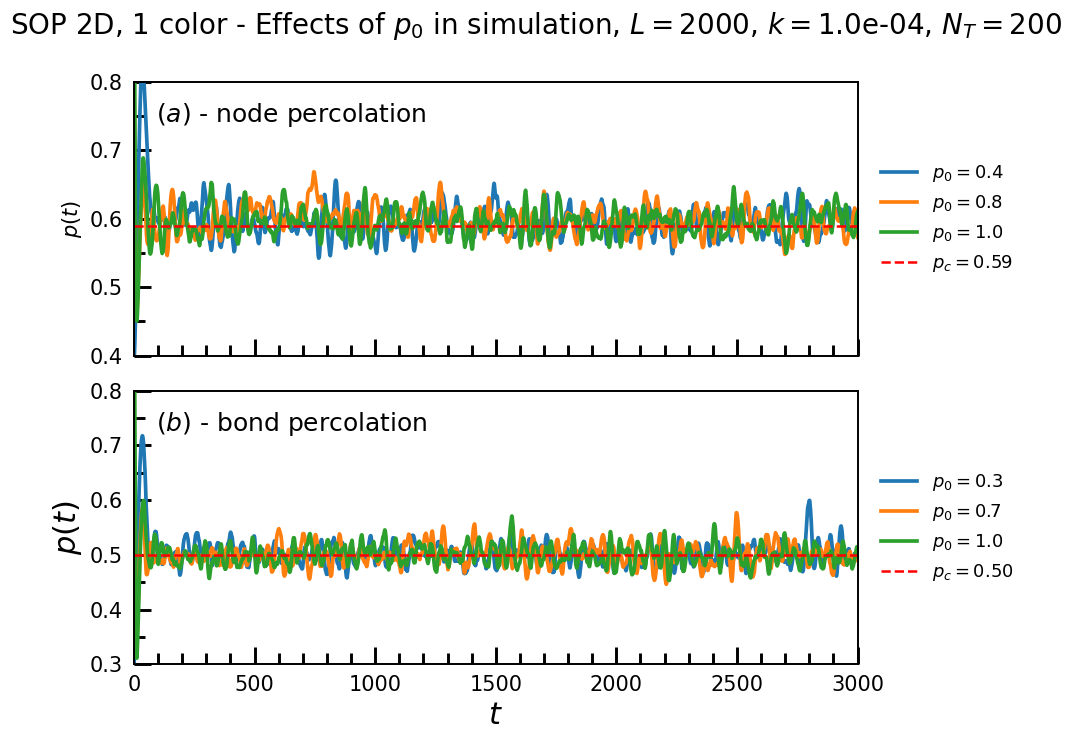

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), sharex=True)


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 15
fontsize_legend = 13
fontsize_labels = 22
thickness = 1.4

p_0_node = [0.4, 0.8, 1.0]
#seeds_name_node = [1819163204, 748540170 , 450131217] #lab
seeds_name_node = [1567861503, 578991113 , 1273693407] #home

p_0_bond = [0.3, 0.7, 1.0]
#seeds_name_bond = [847039001, 971456870, 1767333482] #lab
seeds_name_bond = [417464870, 642617456, 76918351] #home

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', 'd62728']

for i in range(len(seeds_name_node)):
    prop_node_names = data_single_sample('node', num_colors, dim, L, Nt, k, rho, p_0_node[i], seeds_name_node[i])        
    t, pt = prop_node_names["t"], prop_node_names["p_1"]
    axs[0].plot(t, pt, lw=1.9*thickness, label=f'$p_0 = {p_0_node[i]}$', color=colors[i])


for i in range(len(seeds_name_bond)):
    type_perc = 'bond'
    prop_bond_names = data_single_sample('bond', num_colors, dim, L, Nt, k, rho, p_0_bond[i], seeds_name_bond[i])        
    t, pt = prop_bond_names["t"], prop_bond_names["p_1"]
    axs[1].plot(t, pt, lw=1.9*thickness, label=f'$p_0 = {p_0_bond[i]}$', color=colors[i])

xmax =  3000

axs[0].hlines(y=0.59, xmin=0, xmax=xmax, linestyles="--", color='r', lw=1.8, label="$p_c = 0.59$")
axs[1].hlines(y=0.50, xmin=0, xmax=xmax, linestyles="--", color='r', lw=1.8, label="$p_c = 0.50$")

for ax in axs:
    ax.set_xlim([0, xmax])
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

    # Y: major ticks a cada 1 unidade
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))

    # Opcional: ajuste visual dos ticks
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=12, width=1.5*thickness, pad = 8)
    ax.tick_params(axis='x',   which='minor', direction='in', length=8, width=1.5*thickness)   # only x minor
    ax.tick_params(axis='y',   which='minor', direction='in', length=8, width=1.5*thickness)   # only x minor
    
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              framealpha=0.0, fontsize=fontsize_legend)
    
    ax.set_ylabel("$p(t)$",fontsize=fontsize_labels)

axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes,
            ha="left", va="top", fontsize=18)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes,
            ha="left", va="top", fontsize=18)



axs[0].set_ylim([0.4, 0.8])
axs[1].set_ylim([0.3, 0.8])


#axs[0].legend(framealpha=0.0,fontsize=fontsize_ticks)

axs[0].set_ylabel("$p(t)$",fontsize=fontsize_ticks)
#axs[0].tick_params(axis='both', labelsize=fontsize_ticks, width=thickness, length = 4.0, direction='in')

#axs[1].set_title("Bond Percolation")
#axs[1].legend(framealpha=0.0,fontsize=fontsize_ticks)
axs[1].set_xlabel("$t$",fontsize=fontsize_labels)


plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.suptitle(f"SOP 2D, 1 color - Effects of $p_0$ in simulation, $L = {L}$, $k = ${k:.1e}, $N_T = {Nt}$", fontsize=20, y=1.05)
plt.savefig(savepath_TS_1_color + "/p0_effects_L_2000.pdf")
plt.show()

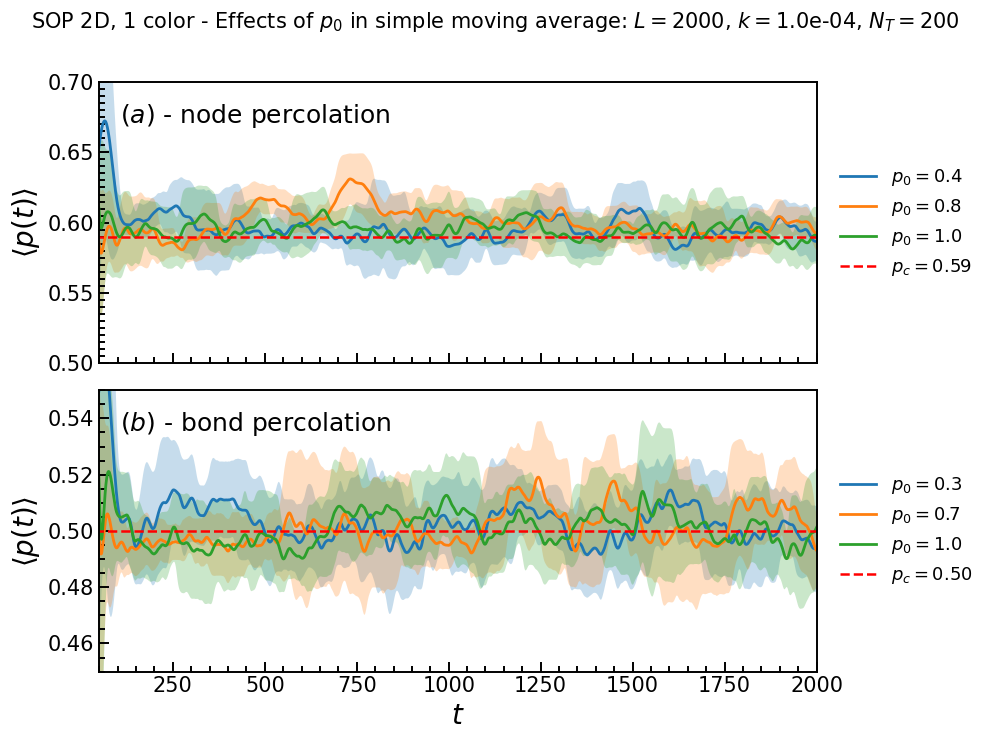

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo (para janela par funciona como 'centered' padrão)
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_legend = 13
fontsize_labels = 20
fontsize_ticks = 15
thickness = 1.4

p_0_node = [0.4, 0.8, 1.0]
#seeds_name_node = [1819163204, 748540170 , 450131217] #lab
seeds_name_node = [1567861503, 578991113 , 1273693407] #home

p_0_bond = [0.3, 0.7, 1.0]
#seeds_name_bond = [847039001, 971456870, 1767333482] #lab
seeds_name_bond = [417464870, 642617456, 76918351] #home
# p0 fixo
window = 100  # range da janela
rho = 1.0

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 7), sharex=True)

# --------- NODE ---------
for i, seed in enumerate(seeds_name_node):
    prop = data_single_sample('node', num_colors, dim, L, Nt, k, rho, p_0_node[i], seed)
    t, pt = prop["t"], prop["p_1"]

    # média e desvio por janela
    tc, mu, sd = rolling_mean_std(t, pt, window)

    # (opcional) trace a série original fraquinha atrás:
    # axs[0].plot(t, pt, lw=1.0, alpha=0.25, color=colors[i])

    axs[0].plot(tc, mu, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_node[i]}$')
    axs[0].fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[i], linewidth=0)

# --------- BOND ---------
for i, seed in enumerate(seeds_name_bond):
    prop = data_single_sample('bond', num_colors, dim, L, Nt, k, rho, p_0_bond[i], seed)
    t, pt = prop["t"], prop["p_1"]

    tc, mu, sd = rolling_mean_std(t, pt, window)

    # axs[1].plot(t, pt, lw=1.0, alpha=0.25, color=colors[i])  # opcional
    axs[1].plot(tc, mu, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_bond[i]}$')
    axs[1].fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[i], linewidth=0)

axs[0].hlines(y=0.59, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8, label="$p_c = 0.59$")
axs[1].hlines(y=0.50, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8, label="$p_c = 0.50$")

# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 2000])
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=7, width=thickness)
    ax.tick_params(axis='x',   which='minor', direction='in', length=4, width=thickness)
    ax.tick_params(axis='y',   which='minor', direction='in', length=4, width=thickness)

    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              framealpha=0.0, fontsize=fontsize_legend)
    ax.set_ylabel(r"$\langle p(t) \rangle$", fontsize=fontsize_labels)



axs[0].yaxis.set_major_locator(MultipleLocator(0.05))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.005))

axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes, ha="left", va="top", fontsize=18)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes, ha="left", va="top", fontsize=18)

axs[0].set_ylim([0.5,0.7])
axs[1].set_ylim([0.45,0.55])

axs[1].yaxis.set_major_locator(MultipleLocator(0.02))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.005))


axs[1].set_xlabel("$t$", fontsize=fontsize_labels)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.suptitle(f"SOP 2D, 1 color - Effects of $p_0$ in simple moving average: $L = {L}$, $k = ${k:.1e}, $N_T = {Nt}$", fontsize=15, y=1.05)
plt.savefig(savepath_TS_1_color + "/rolling_mean_pt_2D_1color.pdf")
plt.show()

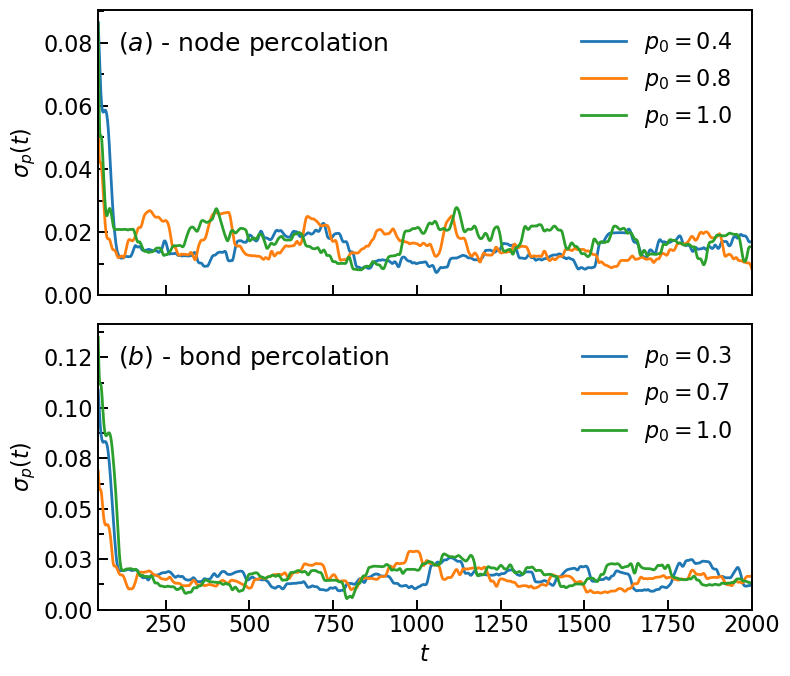

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 16
thickness = 1.4

p_0_node = [0.4, 0.8, 1.0]
seeds_name_node = [1819163204, 748540170 , 450131217]  # lab

p_0_bond = [0.3, 0.7, 1.0]
seeds_name_bond = [847039001, 971456870, 1767333482]  # lab

window = 100
rho = 1.0

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 7), sharex=True)

# --------- NODE: plota sigma_p(t) ---------
for i, seed in enumerate(seeds_name_node):
    prop = data_single_sample('node', num_colors, dim, L, Nt, k, rho, p_0_node[i], seed)
    t, pt = prop["t"], prop["p_1"]

    tc, mu, sd = rolling_mean_std(t, pt, window)  # mu não usado aqui
    axs[0].plot(tc, sd, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_node[i]}$')

# --------- BOND: plota sigma_p(t) ---------
for i, seed in enumerate(seeds_name_bond):
    prop = data_single_sample('bond', num_colors, dim, L, Nt, k, rho, p_0_bond[i], seed)
    t, pt = prop["t"], prop["p_1"]

    tc, mu, sd = rolling_mean_std(t, pt, window)
    axs[1].plot(tc, sd, lw=2.0, color=colors[i], label=f'$p_0 = {p_0_bond[i]}$')

from matplotlib.ticker import AutoMinorLocator, MaxNLocator, FormatStrFormatter
# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 2000])

    # deixa o Matplotlib escolher ~6 ticks "bons" e mostra os valores
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))      # 5–6 ticks
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # duas casas
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))       # 1 minor entre majors

    # opcional: garante que 0 fica visível e dá margem
    ax.set_ylim(bottom=0)          # ou: ax.margins(y=0.05)

    for spine in ax.spines.values():
        spine.set_linewidth(thickness)

    ax.tick_params(axis='both', which='major', direction='in',
                   labelsize=fontsize_ticks, length=7, width=thickness)
    ax.tick_params(axis='x', which='minor', direction='in', length=4, width=thickness)
    ax.tick_params(axis='y', which='minor', direction='in', length=4, width=thickness)

# linhas-guia (opcionais; ajuste valores se fizer sentido para sigma)
# axs[0].hlines(y=0.06, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8)
# axs[1].hlines(y=0.05, xmin=0, xmax=2000, linestyles="--", color='r', lw=1.8)

axs[0].text(0.03, 0.93, r"$(a)$ - node percolation", transform=axs[0].transAxes, ha="left", va="top", fontsize=18)
axs[1].text(0.03, 0.93, r"$(b)$ - bond percolation", transform=axs[1].transAxes, ha="left", va="top", fontsize=18)

axs[0].set_ylabel(r"$\sigma_p(t)$", fontsize=fontsize_ticks)
axs[1].set_xlabel("$t$", fontsize=fontsize_ticks)
axs[1].set_ylabel(r"$\sigma_p(t)$", fontsize=fontsize_ticks)

axs[0].legend(framealpha=0.0, fontsize=fontsize_ticks)
axs[1].legend(framealpha=0.0, fontsize=fontsize_ticks)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig(savepath_TS + "/rolling_mean_std_2D_1color.pdf")
plt.show()


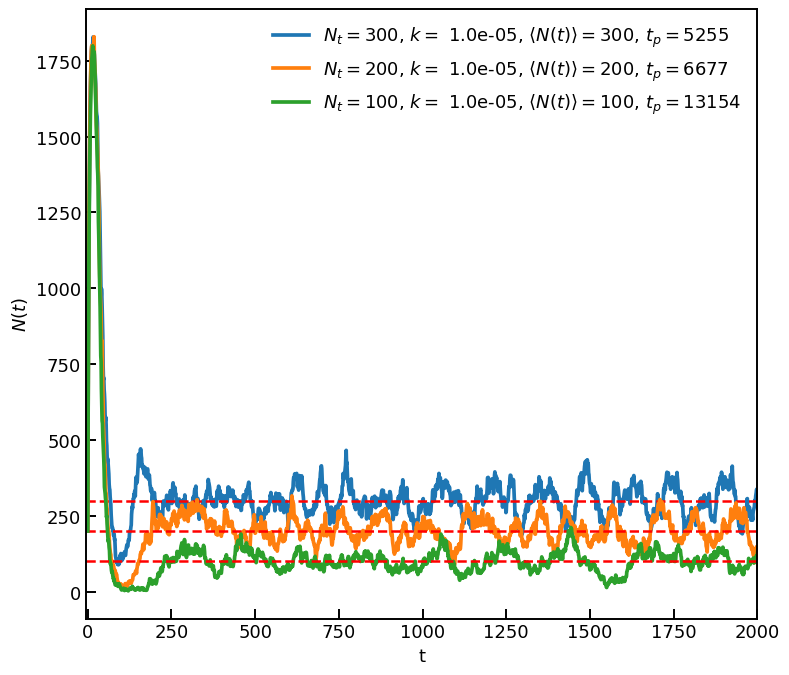

In [ ]:
type_perc = 'bond'
num_colors = 1
dim = 2
L= 2000
Nt = 200
k = 1.0e-04 
rho = 1.0
p0 = 1.0
seed = 308536418

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 7), sharex=True)


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

# --- Node Percolation ---
#type_percolation_node = "node"


p0 = 1.0
k_values = [1.0e-05, 1.0e-05, 1.0e-05]
Nt_values = [300, 200, 100]
seeds_name = [1897561577, 1356373728, 1918868487]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(len(seeds_name)):
    prop_node_names = data_single_sample('bond', num_colors, dim, L, Nt_values[i], k_values[i], rho, p0, seeds_name[i])        
    t, nt = prop_node_names["t"], prop_node_names["N_1"]
    data_filter = nt[400:]
    nt_mean = np.mean(data_filter)
    
    ax.plot(t, nt, lw=1.9*thickness, label=f'$N_t = {Nt_values[i]}$, $k =$ {k_values[i]:.1e}, $\\langle N(t) \\rangle = {nt_mean:.0f}$, $t_p = {max(t)}$', color=colors[i])
    ax.axhline(y=nt_mean, xmin=min(t), xmax=max(t), linestyle="--", color='r', lw=1.8)

ax.set_xlim([-5, 2000])
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

# ax.tick_params(axis='both', labelsize=fontsize_ticks)
# ax.xaxis.set_minor_locator(AutoMinorLocator())

# # Y: major ticks a cada 1 unidade
# ax.yaxis.set_major_locator(MultipleLocator(0.1))
# ax.yaxis.set_minor_locator(MultipleLocator(0.05))

# # Opcional: ajuste visual dos ticks
ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=7, width=thickness)
ax.tick_params(axis='x',   which='minor', direction='in', length=4, width=thickness)   # only x minor
ax.tick_params(axis='y',   which='minor', direction='in', length=4, width=thickness)   # only x minor


#axs[0].set_title("Node Percolation")
ax.legend(framealpha=0.0,fontsize=fontsize_ticks)

ax.set_ylabel("$p(t)$",fontsize=fontsize_ticks)
#axs[0].tick_params(axis='both', labelsize=fontsize_ticks, width=thickness, length = 4.0, direction='in')

#axs[1].set_title("Bond Percolation")

ax.set_xlabel("t",fontsize=fontsize_ticks)
ax.set_ylabel("$N(t)$",fontsize=fontsize_ticks)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig(savepath_TS + "/Fig3.pdf")
plt.show()

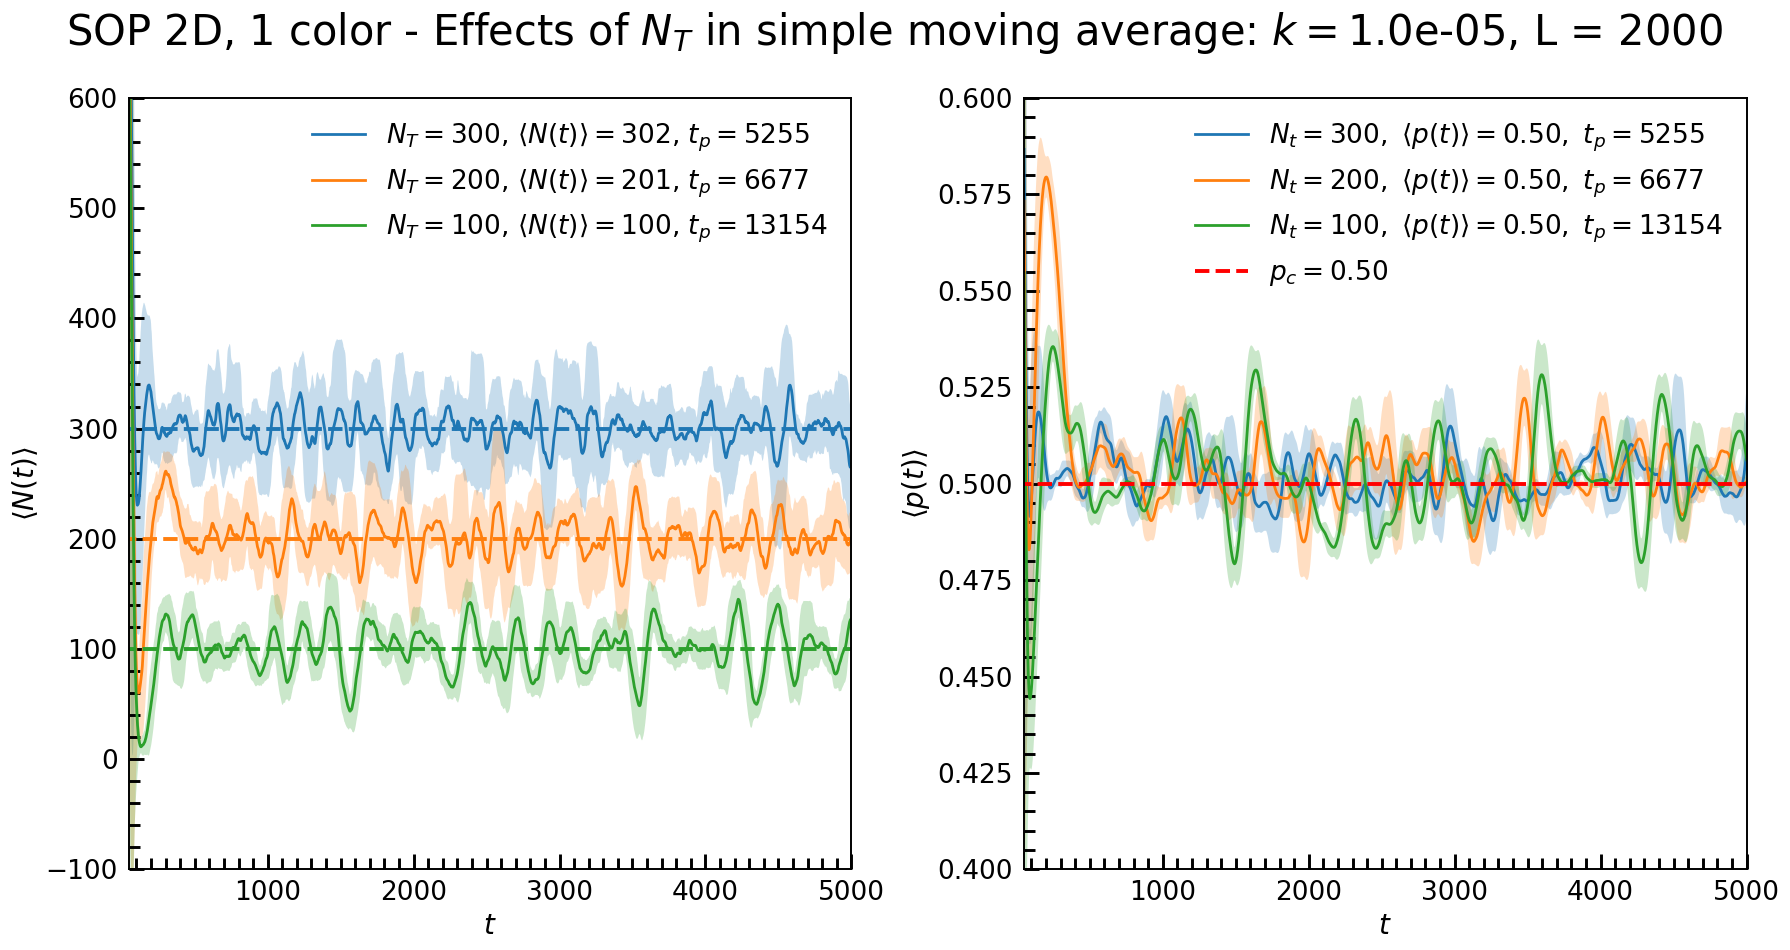

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# DO WITH K=1.0e-05 AND NT = 200, 300, 400

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo (para janela par funciona como 'centered' padrão)
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

thickness = 1.4
fontsize_ticks = 19
fontsize_legend = 15
fontsize_labels = 20

# --- Node Percolation ---
#type_percolation_node = "node"

type_perc = 'bond'
num_colors = 1
dim = 2
L= 2000
Nt = 200
k = 1.0e-04 
rho = 1.0

p0 = 1.0
k_values = [1.0e-05, 1.0e-05, 1.0e-05]
Nt_values = [300, 200, 100]
seeds_name = [1897561577, 1356373728, 1918868487]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

window = 100
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 9), sharex=True)

# --------- NODE ---------
for i, seed in enumerate(seeds_name):
    prop = data_single_sample('bond', num_colors, dim, L, Nt_values[i], k_values[i], rho, p0, seed)
    t, nt, pt = prop["t"], prop["N_1"], prop["p_1"]

    # média e desvio por janela
    tc, mu_n, sd_n = rolling_mean_std(t, nt, window)
    tc, mu_p, sd_p = rolling_mean_std(t, pt, window)
    
    n_mean = np.mean(mu_n)
    p_mean = np.mean(mu_p)
    
    # (opcional) trace a série original fraquinha atrás:
    # axs[0].plot(t, pt, lw=1.0, alpha=0.25, color=colors[i])

    axs[0].plot(tc, mu_n, lw=2.0, color=colors[i], label=f'$N_T = {Nt_values[i]}$, $\\langle N(t) \\rangle = {n_mean:.0f}$, $t_p = {max(t)}$')
    axs[0].fill_between(tc, mu_n - sd_n, mu_n + sd_n, alpha=0.25, color=colors[i], linewidth=0)
    
    axs[1].plot(tc, mu_p, lw=2.0, color=colors[i], label=fr'$N_t = {Nt_values[i]},\ \langle p(t) \rangle = {p_mean:.2f},\ t_p = {max(t)}$')
    axs[1].fill_between(tc, mu_p - sd_p, mu_p + sd_p, alpha=0.25, color=colors[i], linewidth=0)

    axs[0].hlines(y=Nt_values[i], xmin=0, xmax=5000, linestyles="--", color=colors[i], lw=2*thickness)

axs[1].hlines(y=0.5, xmin=0, xmax=5000, linestyles="--", color="r", lw=2*thickness, label='$p_c = 0.50$')    
# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 5000])
    
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)
    ax.tick_params(axis='both', labelsize=fontsize_ticks)
    ax.xaxis.set_major_locator(MultipleLocator(1000))
    ax.xaxis.set_minor_locator(MultipleLocator(100))

    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=11, width=1.5*thickness, pad=8)
    ax.tick_params(axis='x',   which='minor', direction='in', length=8, width=1.5*thickness)
    ax.tick_params(axis='y',   which='minor', direction='in', length=8, width=1.5*thickness)
    ax.set_xlabel("$t$", fontsize=fontsize_labels)
    ax.legend(framealpha=0.0, fontsize=fontsize_ticks)

axs[0].yaxis.set_major_locator(MultipleLocator(100))
axs[0].yaxis.set_minor_locator(MultipleLocator(20))

axs[1].yaxis.set_major_locator(MultipleLocator(0.025))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.005))

axs[0].set_ylim([-100, 600])
axs[1].set_ylim([0.40, 0.60])

axs[0].set_ylabel(r"$\langle N(t) \rangle$", fontsize=fontsize_labels)
axs[1].set_ylabel(r"$\langle p(t) \rangle$", fontsize=fontsize_labels)


plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.suptitle(f"SOP 2D, 1 color - Effects of $N_T$ in simple moving average: $k = ${k_values[0]:.1e}, L = {L}", fontsize=30, y=1.05)
plt.savefig(savepath_TS_1_color + "/Nt_effects_2D_L_2000.pdf")
plt.show()

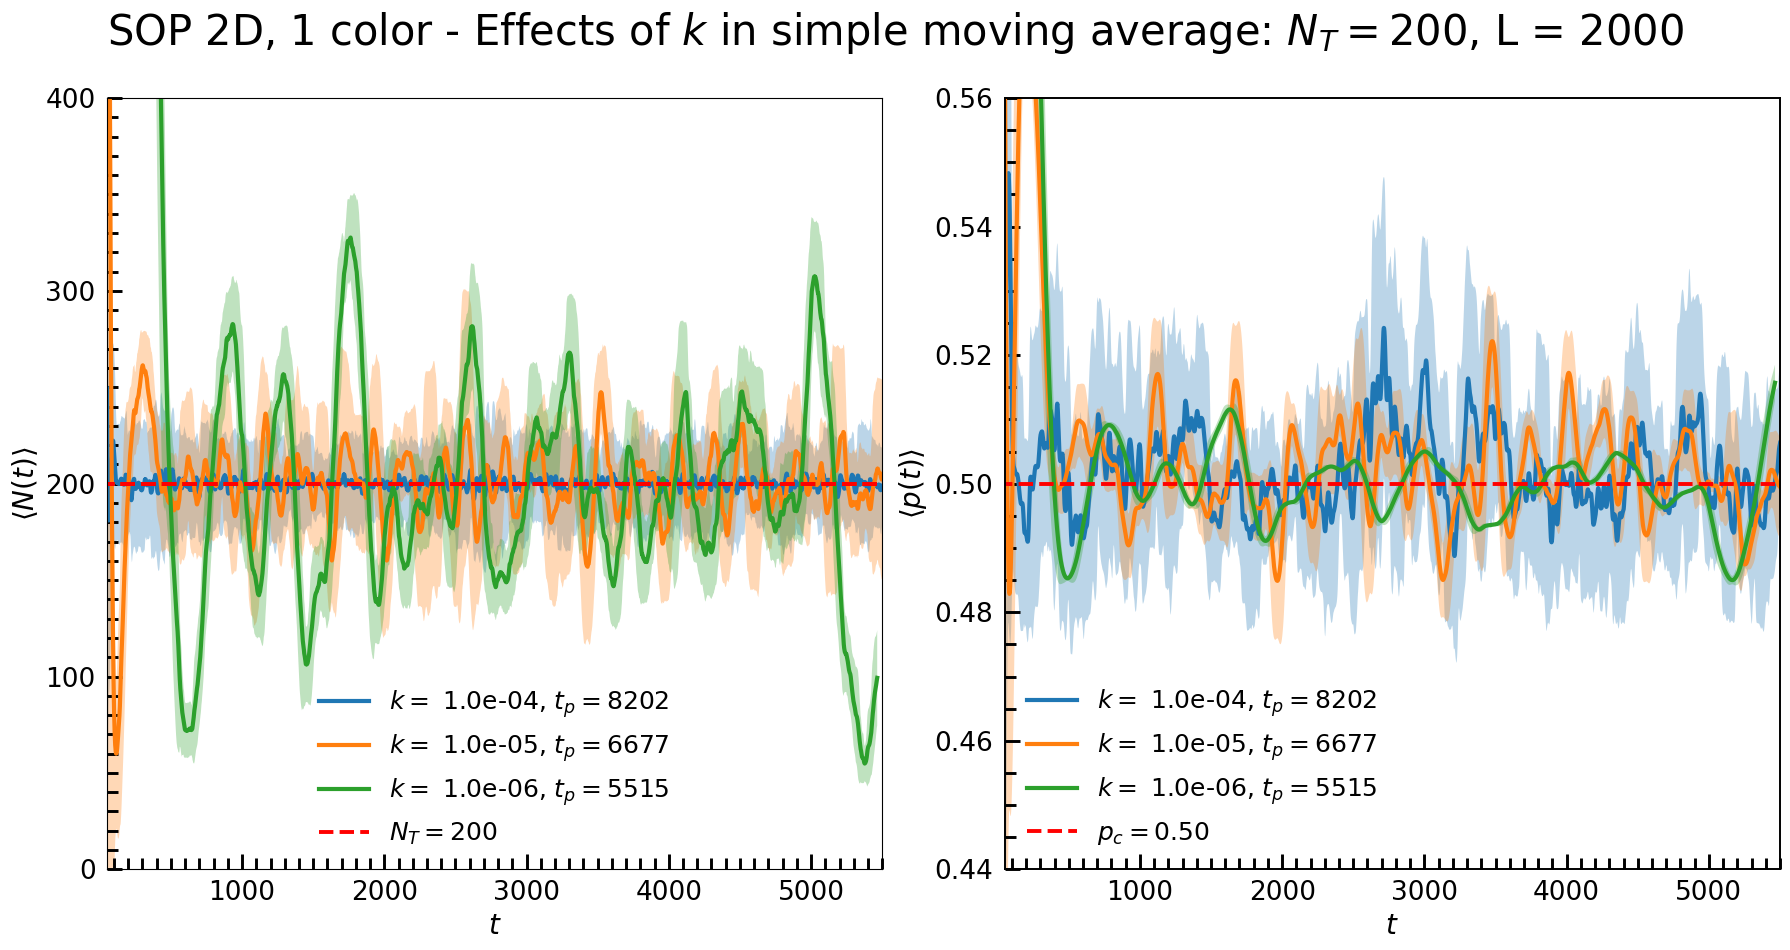

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# DO WITH NT = 200, K=1.0e-04, K=1.0e-05, K=1.0e-06

# ---------- janela deslizante ----------
def rolling_mean_std(t, y, window: int):
    """
    Retorna (t_centrado, media, desvio_padrao) para uma janela deslizante de tamanho 'window'.
    A série resultante fica centrada na janela.
    """
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")

    c = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))

    mean = (c[window:] - c[:-window]) / window
    var = (c2[window:] - c2[:-window]) / window - mean**2
    std = np.sqrt(np.clip(var, 0, None))

    # centraliza no tempo (para janela par funciona como 'centered' padrão)
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std


colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
thickness = 1.4
fontsize_ticks = 19
fontsize_legend = 18
fontsize_labels = 20
# --- Node Percolation ---
#type_percolation_node = "node"

type_perc = 'bond'
num_colors = 1
dim = 2
L= 2000
Nt = 200
k = 1.0e-04 
rho = 1.0

p0 = 1.0
k_values = [1.0e-04, 1.0e-05, 1.0e-06]
Nt_values = [200, 200, 200]
seeds_name = [1861136042, 1356373728, 1009218574]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

window = 100
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 9), sharex=True)

# --------- NODE ---------
for i, seed in enumerate(seeds_name):
    prop = data_single_sample('bond', num_colors, dim, L, Nt_values[i], k_values[i], rho, p0, seed)
    t, nt = prop["t"], prop["N_1"]
    pt = prop["p_1"]
    nt_mean = np.mean(nt[200:])
    pt_mean = np.mean(pt[200:])
    # média e desvio por janela
    tc, mu_n, sd_n = rolling_mean_std(t, nt, window)
    tc, mu_p, sd_p = rolling_mean_std(t, pt, window)

    axs[0].plot(tc, mu_n, lw=3.0, color=colors[i], label=f'$k =$ {k_values[i]:.1e}, $t_p = {max(t)}$')
    axs[0].fill_between(tc, mu_n - sd_n, mu_n + sd_n, alpha=0.30, color=colors[i], linewidth=0)
    axs[0].hlines(y=Nt_values[i], xmin=0, xmax=5500, linestyles="--", color=colors[i], lw=2*thickness)
    
    axs[1].plot(tc, mu_p, lw=3.0, color=colors[i], label=f'$k =$ {k_values[i]:.1e}, $t_p = {max(t)}$')
    axs[1].fill_between(tc, mu_p - sd_p, mu_p + sd_p, alpha=0.30, color=colors[i], linewidth=0)
    
    axs[0].hlines(y=Nt_values[i], xmin=0, xmax=5500, linestyles="--", color='r', lw=2*thickness)

axs[1].hlines(y=0.5, xmin=0, xmax=5500, linestyles="--", color='r', lw=2*thickness, label='$p_c = 0.50$')
axs[0].hlines(y=200, xmin=0, xmax=5500, linestyles="--", color='r', lw=2*thickness, label='$N_T = 200$')

# ---------- estética ----------
for ax in axs:
    ax.set_xlim([float(tc[0]), 5500])
    ax.xaxis.set_major_locator(MultipleLocator(1000))
    ax.xaxis.set_minor_locator(MultipleLocator(100))
    ax.tick_params(axis='both', which='major', direction='in', labelsize=fontsize_ticks, length=11, width=1.5*thickness, pad=8)
    ax.tick_params(axis='x',   which='minor', direction='in', length=8, width=1.5*thickness)
    ax.tick_params(axis='y',   which='minor', direction='in', length=8, width=1.5*thickness)
    ax.set_xlabel("$t$", fontsize=fontsize_labels)
    ax.legend(framealpha=0.0, fontsize=fontsize_legend)

axs[0].set_ylim([0, 400])
axs[1].set_ylim([0.44, 0.56])
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

axs[0].tick_params(axis='both', labelsize=fontsize_ticks)
axs[0].yaxis.set_major_locator(MultipleLocator(100))
axs[0].yaxis.set_minor_locator(MultipleLocator(10))

axs[1].yaxis.set_major_locator(MultipleLocator(0.02))
axs[1].yaxis.set_minor_locator(MultipleLocator(0.005))

axs[0].set_ylabel(r"$\langle N(t) \rangle$", fontsize=fontsize_labels)
axs[1].set_ylabel(r"$\langle p(t) \rangle$", fontsize=fontsize_labels)

plt.subplots_adjust(hspace=0.15)
fig.tight_layout(rect=[0, 0, 1, 0.98])

fig.suptitle(f"SOP 2D, 1 color - Effects of $k$ in simple moving average: $N_T = {Nt}$, L = {L}", fontsize=30, y=1.05)

plt.savefig(savepath_TS_1_color + "/k_effects_2D_L_2000.pdf")
plt.show()

## 2 COLORS